# 04b — Stream 5 generation notebook

This notebook loads the exported Stream 5 champion checkpoint, applies the selected calibration tuple, generates synthetic paths for the requested splits, saves the canonical generation artifacts, and writes a short diagnostics summary for the next validation notebook.

The notebook is intentionally structured and numbered so each stage is easy to rerun in Colab.

## 1. Imports, paths, and runtime setup

This cell imports the libraries used for generation, fixes the random seeds, sets the Drive data directory, and declares the input and output artifact paths.

In [1]:
# ============================================================
# 0. Ensure Google Drive is available
# This cell checks whether the project data directory is already
# accessible. If not, it mounts Drive safely.
# ============================================================

import os
from pathlib import Path

DRIVE_ROOT = Path("/content/drive")
DATA_DIR = DRIVE_ROOT / "MyDrive/energy_synthetic_data/data"

if DATA_DIR.exists():
    print("Drive already available:", DATA_DIR)
else:
    from google.colab import drive

    mountpoint = "/content/drive"
    if os.path.exists(mountpoint) and os.path.isdir(mountpoint) and os.listdir(mountpoint):
        mountpoint = "/content/gdrive"

    drive.mount(mountpoint, force_remount=False)

    DRIVE_ROOT = Path(mountpoint)
    DATA_DIR = DRIVE_ROOT / "MyDrive/energy_synthetic_data/data"
    print("Mounted Drive at:", DRIVE_ROOT)

print("Using DATA_DIR:", DATA_DIR)

Mounted at /content/drive
Mounted Drive at: /content/drive
Using DATA_DIR: /content/drive/MyDrive/energy_synthetic_data/data


In [2]:
# ------------------------------------------------------------
# Diagnose which Stream 5 artifacts actually exist on Drive
# ------------------------------------------------------------
from pathlib import Path

candidates = [
    Path("/content/drive/MyDrive/energy_synthetic_data/data"),
    Path("/content/gdrive/MyDrive/energy_synthetic_data/data"),
]

for base in candidates:
    print("\nBASE:", base)
    print("exists:", base.exists())
    if base.exists():
        for name in [
            "returns_s5.parquet",
            "norm_stats_s5.json",
            "conditioning_stats_s5.json",
            "jump_labels_s5.json",
            "s5_champion_export/s5_diffusion_champion.pt",
            "s5_champion_export/s5_diffusion_champion_manifest.json",
        ]:
            p = base / name
            print(f"  {name}: {p.exists()}")


BASE: /content/drive/MyDrive/energy_synthetic_data/data
exists: True
  returns_s5.parquet: True
  norm_stats_s5.json: True
  conditioning_stats_s5.json: True
  jump_labels_s5.json: True
  s5_champion_export/s5_diffusion_champion.pt: True
  s5_champion_export/s5_diffusion_champion_manifest.json: True

BASE: /content/gdrive/MyDrive/energy_synthetic_data/data
exists: False


In [3]:
# ============================================================
# 1. Imports, paths, and runtime setup
# This cell imports libraries, sets plotting/device options,
# seeds randomness, and defines all file paths used below.
# ============================================================

from pathlib import Path
import json, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Reuse DATA_DIR from the mount cell if present; otherwise fall back
# to the standard project location.
try:
    DATA_DIR
except NameError:
    DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")

RETURNS_PATH = DATA_DIR / "returns_s5.parquet"
NORM_PATH = DATA_DIR / "norm_stats_s5.json"
COND_PATH = DATA_DIR / "conditioning_stats_s5.json"
CHAMPION_PT = DATA_DIR / "s5_champion_export" / "s5_diffusion_champion.pt"
CHAMPION_MANIFEST = DATA_DIR / "s5_champion_export" / "s5_diffusion_champion_manifest.json"

OUT_GENERATED = DATA_DIR / "diffusion_generated.parquet"
OUT_SUMMARY_JSON = DATA_DIR / "s5_generation_manifest.json"
OUT_DIAG_CSV = DATA_DIR / "s5_generation_diagnostics.csv"
OUT_LOGSIGS = DATA_DIR / "logsigs_s5_generated.parquet"
PLOT_DIR = DATA_DIR / "s5_generation_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

for p in [RETURNS_PATH, NORM_PATH, COND_PATH, CHAMPION_PT, CHAMPION_MANIFEST]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

print("Using:")
print(" ", RETURNS_PATH)
print(" ", CHAMPION_PT)
print(" ", CHAMPION_MANIFEST)
print("Outputs:")
print(" ", OUT_GENERATED)
print(" ", OUT_SUMMARY_JSON)
print(" ", OUT_DIAG_CSV)
print(" ", OUT_LOGSIGS)

device: cpu
Using:
  /content/drive/MyDrive/energy_synthetic_data/data/returns_s5.parquet
  /content/drive/MyDrive/energy_synthetic_data/data/s5_champion_export/s5_diffusion_champion.pt
  /content/drive/MyDrive/energy_synthetic_data/data/s5_champion_export/s5_diffusion_champion_manifest.json
Outputs:
  /content/drive/MyDrive/energy_synthetic_data/data/diffusion_generated.parquet
  /content/drive/MyDrive/energy_synthetic_data/data/s5_generation_manifest.json
  /content/drive/MyDrive/energy_synthetic_data/data/s5_generation_diagnostics.csv
  /content/drive/MyDrive/energy_synthetic_data/data/logsigs_s5_generated.parquet


## 2. Generation configuration

This cell controls which splits are generated, whether the saved calibration tuple is used as-is, the generation batch size, and whether the optional log-signature artifact is written.

In [4]:
SPLITS_TO_GENERATE = ['val', 'test']
N_SAMPLES_PER_COND = 1            # canonical export uses one synthetic path per real conditioning row
GEN_BATCH_SIZE = 256
N_STEPS_OVERRIDE = None           # keep None to use the saved diffusion-step count
USE_SAVED_CALIBRATION = True
OVERRIDE_CALIBRATION = {
    'threshold': None,
    'temperature': None,
    'jump_scale': None,
}
SAVE_LOGSIGS = True
SIG_DEPTH = 2                     # simple auxiliary logsig export on a 2D path
MAX_PLOT_ROWS_PER_SPLIT = 6

print({
    'splits': SPLITS_TO_GENERATE,
    'n_samples_per_cond': N_SAMPLES_PER_COND,
    'gen_batch_size': GEN_BATCH_SIZE,
    'n_steps_override': N_STEPS_OVERRIDE,
    'save_logsigs': SAVE_LOGSIGS,
    'sig_depth': SIG_DEPTH,
})


{'splits': ['val', 'test'], 'n_samples_per_cond': 1, 'gen_batch_size': 256, 'n_steps_override': None, 'save_logsigs': True, 'sig_depth': 2}


## 3. Load the exported Stream 5 champion and prep metadata

This cell loads the saved champion checkpoint, the selected calibration tuple, the prep parquet, and the transform metadata written by the Stream 5 prep notebook.

In [7]:
returns_s5 = pd.read_parquet(RETURNS_PATH)
with open(NORM_PATH, 'r') as f:
    norm_stats = json.load(f)
with open(COND_PATH, 'r') as f:
    cond_stats = json.load(f)
champion_payload = torch.load(CHAMPION_PT, map_location=device)

if CHAMPION_MANIFEST.exists():
    with open(CHAMPION_MANIFEST, 'r') as f:
        champion_manifest = json.load(f)
else:
    champion_manifest = {}

r_cols = champion_payload['r_cols']
cond_cols = champion_payload['cond_cols']
mask_cols = champion_payload['mask_cols']
jump_cols = champion_payload['jump_cols']
conditioning_dim = int(champion_payload['conditioning_dim'])
hazard_idx = champion_payload.get('hazard_idx', list(range(conditioning_dim - 3, conditioning_dim)))

selected_calibration = champion_payload.get('selected_calibration', {})
if USE_SAVED_CALIBRATION:
    calibration = {
        'threshold': float(selected_calibration['threshold']),
        'temperature': float(selected_calibration['temperature']),
        'jump_scale': float(selected_calibration['jump_scale']),
    }
else:
    calibration = {
        'threshold': float(OVERRIDE_CALIBRATION['threshold']),
        'temperature': float(OVERRIDE_CALIBRATION['temperature']),
        'jump_scale': float(OVERRIDE_CALIBRATION['jump_scale']),
    }

print('Champion config:')
print(json.dumps(champion_payload['config'], indent=2))
print('Calibration used for generation:')
print(json.dumps(calibration, indent=2))

required_cols = ['split', 'seg_id', 'start_idx'] + r_cols + cond_cols + mask_cols + jump_cols
missing = [c for c in required_cols if c not in returns_s5.columns]
if missing:
    raise KeyError(f'Missing required columns in returns_s5.parquet: {missing[:10]}')

sel = returns_s5.loc[returns_s5['split'].isin(SPLITS_TO_GENERATE)].copy().reset_index(drop=True)
if len(sel) == 0:
    raise RuntimeError(f'No rows found for splits {SPLITS_TO_GENERATE}')

print('Selected rows by split:')
print(sel['split'].value_counts(dropna=False))
print('conditioning_dim:', conditioning_dim)
print('hazard_idx:', hazard_idx)
print('target_kind:', norm_stats.get('target_kind'))


Champion config:
{
  "seq_len": 72,
  "n_diffusion_steps": 128,
  "base_channels": 96,
  "dropout": 0.05,
  "batch_size": 256,
  "num_workers": 2,
  "lr": 0.0001,
  "weight_decay": 0.0001,
  "warmup_epochs": 5,
  "max_epochs": 80,
  "min_epochs": 25,
  "patience": 20,
  "min_delta": 0.001,
  "grad_clip": 1.0,
  "ema_decay": 0.995,
  "denoise_target": "eps",
  "lambda_mask": 0.75,
  "lambda_jump": 1.25,
  "lambda_var": 0.1,
  "lambda_tail": 0.05,
  "lambda_haz": 0.1,
  "lambda_share": 0.25,
  "tail_q": 0.95,
  "focal_gamma": 1.5,
  "jump_threshold": 0.5,
  "checkpoint_every": 5,
  "n_probe_rows": 256,
  "central_mass_tau": 0.2,
  "calib_thresholds": [
    0.65,
    0.7,
    0.75,
    0.8,
    0.85,
    0.9
  ],
  "calib_temperatures": [
    1.0,
    1.2,
    1.4
  ],
  "calib_jump_scales": [
    0.75,
    0.85,
    0.95,
    1.0
  ],
  "calib_min_recall": 0.05,
  "calib_min_pred_share_frac": 0.25,
  "calib_max_pred_share_mult": 3.0,
  "n_calib_draws": 3
}
Calibration used for generation

## 4. Model blocks and diffusion scheduler

This cell recreates only the pieces needed for inference: timestep embedding, conditioning projector, residual U-Net blocks, and the diffusion scheduler.

In [8]:
def make_beta_schedule(n_steps: int, start: float = 1e-4, end: float = 2e-2):
    return torch.linspace(start, end, n_steps, dtype=torch.float32)

class DiffusionScheduler:
    def __init__(self, n_steps: int, device: torch.device):
        betas = make_beta_schedule(n_steps).to(device)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]], dim=0)

        self.n_steps = n_steps
        self.betas = betas
        self.alphas = alphas
        self.alphas_cumprod = alphas_cumprod
        self.alphas_cumprod_prev = alphas_cumprod_prev
        self.sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
        self.sqrt_recip_alphas_cumprod = torch.sqrt(1.0 / alphas_cumprod)
        self.sqrt_recipm1_alphas_cumprod = torch.sqrt(1.0 / alphas_cumprod - 1.0)
        self.posterior_variance = (
            betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        ).clamp(min=1e-20)
        self.posterior_mean_coef1 = (
            betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        )
        self.posterior_mean_coef2 = (
            (1.0 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - alphas_cumprod)
        )

    def _extract(self, a: torch.Tensor, t: torch.Tensor, x_shape):
        out = a.gather(0, t)
        return out.view(-1, *([1] * (len(x_shape) - 1)))

    def predict_v(self, x0: torch.Tensor, noise: torch.Tensor, t: torch.Tensor):
        return (
            self._extract(self.sqrt_alphas_cumprod, t, x0.shape) * noise
            - self._extract(self.sqrt_one_minus_alphas_cumprod, t, x0.shape) * x0
        )

    def predict_x0_from_eps(self, xt: torch.Tensor, t: torch.Tensor, eps: torch.Tensor):
        return (
            self._extract(self.sqrt_recip_alphas_cumprod, t, xt.shape) * xt
            - self._extract(self.sqrt_recipm1_alphas_cumprod, t, xt.shape) * eps
        )

    def predict_x0_from_v(self, xt: torch.Tensor, t: torch.Tensor, v: torch.Tensor):
        sqrt_acp = self._extract(self.sqrt_alphas_cumprod, t, xt.shape)
        sqrt_om = self._extract(self.sqrt_one_minus_alphas_cumprod, t, xt.shape)
        return sqrt_acp * xt - sqrt_om * v

def timestep_embedding(timesteps: torch.Tensor, dim: int, max_period: int = 10000):
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period) * torch.arange(0, half, dtype=torch.float32, device=timesteps.device) / max(half, 1)
    )
    args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=1)
    if dim % 2:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)
    return emb

class TimeEmbedding(nn.Module):
    def __init__(self, emb_dim: int):
        super().__init__()
        self.emb_dim = emb_dim
        self.net = nn.Sequential(
            nn.Linear(emb_dim, emb_dim * 4),
            nn.SiLU(),
            nn.Linear(emb_dim * 4, emb_dim),
        )

    def forward(self, t: torch.Tensor):
        return self.net(timestep_embedding(t, self.emb_dim))

class ConditionProjector(nn.Module):
    def __init__(self, cond_dim: int, emb_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, emb_dim * 2),
            nn.SiLU(),
            nn.Linear(emb_dim * 2, emb_dim),
        )

    def forward(self, cond: torch.Tensor):
        return self.net(cond)

class ResidualBlock1D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, emb_dim: int, dropout: float):
        super().__init__()
        self.norm1 = nn.GroupNorm(num_groups=min(8, in_ch), num_channels=in_ch)
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(num_groups=min(8, out_ch), num_channels=out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, in_ch * 2)
        self.skip = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, emb: torch.Tensor):
        h = self.norm1(x)
        scale, shift = self.emb_proj(emb).chunk(2, dim=1)
        h = h * (1.0 + scale.unsqueeze(-1)) + shift.unsqueeze(-1)
        h = F.silu(h)
        h = self.conv1(h)
        h = self.norm2(h)
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)
        return h + self.skip(x)

class Downsample1D(nn.Module):
    def __init__(self, ch: int):
        super().__init__()
        self.op = nn.Conv1d(ch, ch, kernel_size=4, stride=2, padding=1)
    def forward(self, x):
        return self.op(x)

class Upsample1D(nn.Module):
    def __init__(self, ch: int):
        super().__init__()
        self.op = nn.ConvTranspose1d(ch, ch, kernel_size=4, stride=2, padding=1)
    def forward(self, x):
        return self.op(x)

class JumpAwareUNet1D(nn.Module):
    def __init__(self, seq_len: int, cond_dim: int, base_channels: int, dropout: float):
        super().__init__()
        emb_dim = base_channels * 4
        self.seq_len = seq_len
        self.time_emb = TimeEmbedding(emb_dim)
        self.cond_emb = ConditionProjector(cond_dim, emb_dim)
        self.in_proj = nn.Conv1d(1, base_channels, kernel_size=3, padding=1)
        self.down1 = ResidualBlock1D(base_channels, base_channels, emb_dim, dropout)
        self.ds1 = Downsample1D(base_channels)
        self.down2 = ResidualBlock1D(base_channels, base_channels * 2, emb_dim, dropout)
        self.ds2 = Downsample1D(base_channels * 2)
        self.mid = ResidualBlock1D(base_channels * 2, base_channels * 4, emb_dim, dropout)
        self.us2 = Upsample1D(base_channels * 4)
        self.up2 = ResidualBlock1D(base_channels * 4 + base_channels * 2, base_channels * 2, emb_dim, dropout)
        self.us1 = Upsample1D(base_channels * 2)
        self.up1 = ResidualBlock1D(base_channels * 2 + base_channels, base_channels, emb_dim, dropout)
        self.out_norm = nn.GroupNorm(num_groups=min(8, base_channels), num_channels=base_channels)
        self.eps_head = nn.Conv1d(base_channels, 1, kernel_size=1)
        self.mask_head = nn.Conv1d(base_channels, 1, kernel_size=1)
        self.jump_head = nn.Conv1d(base_channels, 1, kernel_size=1)

    def forward(self, xt: torch.Tensor, t: torch.Tensor, cond: torch.Tensor):
        x = xt.unsqueeze(1)
        emb = self.time_emb(t) + self.cond_emb(cond)
        x0 = self.in_proj(x)
        d1 = self.down1(x0, emb)
        h = self.ds1(d1)
        d2 = self.down2(h, emb)
        h = self.ds2(d2)
        h = self.mid(h, emb)
        h = self.us2(h)
        if h.shape[-1] != d2.shape[-1]:
            h = F.interpolate(h, size=d2.shape[-1], mode='nearest')
        h = torch.cat([h, d2], dim=1)
        h = self.up2(h, emb)
        h = self.us1(h)
        if h.shape[-1] != d1.shape[-1]:
            h = F.interpolate(h, size=d1.shape[-1], mode='nearest')
        h = torch.cat([h, d1], dim=1)
        h = self.up1(h, emb)
        h = self.out_norm(h)
        h = F.silu(h)
        eps = self.eps_head(h).squeeze(1)
        mask_logits = self.mask_head(h).squeeze(1)
        gate_scale = (1.0 - t.float() / max(1, scheduler.n_steps - 1)).unsqueeze(1)
        jump = self.jump_head(h).squeeze(1) * gate_scale
        return eps, mask_logits, jump

scheduler = DiffusionScheduler(
    n_steps=int(N_STEPS_OVERRIDE) if N_STEPS_OVERRIDE is not None else int(champion_payload['config']['n_diffusion_steps']),
    device=device,
)


## 5. Load the champion model

This cell reconstructs the saved U-Net, loads the state dict, and checks that the conditioning width matches the prep artifact.

In [9]:
cfg_saved = champion_payload['config']
model = JumpAwareUNet1D(
    seq_len=int(cfg_saved['seq_len']),
    cond_dim=conditioning_dim,
    base_channels=int(cfg_saved['base_channels']),
    dropout=float(cfg_saved['dropout']),
).to(device)
model.load_state_dict(champion_payload['model_state_dict'], strict=True)
model.eval()

print('Loaded champion model.')
print('best_probe_epoch:', champion_payload.get('best_probe_epoch'))
print('best_probe_selection_score:', champion_payload.get('best_probe_selection_score'))
print('conditioning_dim checkpoint:', champion_payload['conditioning_dim'])
print('conditioning_dim current:', conditioning_dim)
if int(champion_payload['conditioning_dim']) != conditioning_dim:
    raise ValueError('conditioning_dim mismatch between checkpoint and prep artifact')


Loaded champion model.
best_probe_epoch: 78
best_probe_selection_score: 0.8115713829586695
conditioning_dim checkpoint: 19
conditioning_dim current: 19


## 6. Sampling, calibration, and inverse-transform helpers

This cell defines the reverse-diffusion sampler, applies the saved jump calibration tuple, and provides helpers for inverse-transforming generated paths back to raw differences.

In [10]:
@torch.no_grad()
def ddpm_sample(model_for_eval: nn.Module, cond: torch.Tensor, n_steps: int | None = None):
    model_for_eval.eval()
    n_steps = scheduler.n_steps if n_steps is None else n_steps
    x = torch.randn(cond.shape[0], len(r_cols), device=device)
    final_mask_prob = None
    final_jump = None

    for step in reversed(range(n_steps)):
        t = torch.full((cond.shape[0],), step, device=device, dtype=torch.long)
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            pred_eps, mask_logits, jump_pred = model_for_eval(x, t, cond)

        if cfg_saved['denoise_target'] == 'eps':
            x0_hat = scheduler.predict_x0_from_eps(x, t, pred_eps)
        else:
            x0_hat = scheduler.predict_x0_from_v(x, t, pred_eps)
        x0_hat = x0_hat.clamp(-8.0, 8.0)

        if step > 0:
            mean = (
                scheduler._extract(scheduler.posterior_mean_coef1, t, x.shape) * x0_hat
                + scheduler._extract(scheduler.posterior_mean_coef2, t, x.shape) * x
            )
            var = scheduler._extract(scheduler.posterior_variance, t, x.shape)
            x = mean + torch.sqrt(var) * torch.randn_like(x)
        else:
            x = x0_hat

        if step == 0:
            final_mask_prob = torch.sigmoid(mask_logits)
            final_jump = jump_pred

    return x.detach(), final_mask_prob.detach(), final_jump.detach()

def apply_jump_calibration(
    x_sample: torch.Tensor,
    mask_prob: torch.Tensor,
    jump_pred: torch.Tensor,
    threshold: float,
    temperature: float = 1.0,
    jump_scale: float = 1.0,
):
    eps = 1e-6
    mask_prob = mask_prob.clamp(eps, 1.0 - eps)
    logits = torch.logit(mask_prob)
    cal_prob = torch.sigmoid(logits / temperature)
    gate = (cal_prob >= threshold).float()
    x_adj = x_sample + gate * (jump_scale * jump_pred)
    return x_adj, cal_prob, gate

def inverse_standardized_target(x_std: np.ndarray, norm_stats: dict):
    x_unstd = x_std * float(norm_stats['target_std']) + float(norm_stats['target_mean'])
    target_kind = norm_stats.get('target_kind', 'diff')
    if target_kind == 'asinh_diff':
        scale = float(norm_stats.get('asinh_scale', 1.0))
        return np.sinh(x_unstd) * scale
    elif target_kind == 'diff':
        return x_unstd
    else:
        raise ValueError(f'Unknown target_kind: {target_kind}')

def reconstruct_price_paths(raw_diff_arr: np.ndarray, p0_arr: np.ndarray):
    # returns path levels after each diff step; shape (n, T)
    return p0_arr[:, None] + np.cumsum(raw_diff_arr, axis=1)


## 7. Generate the selected splits

This cell runs reverse diffusion in batches, applies the saved calibration tuple, and collects the generated paths, jump probabilities, and calibrated gates.

In [13]:
sel = sel.sort_values(['split', 'start_idx']).reset_index(drop=True).copy()
all_batches = []
diag_rows = []

for split_name, df_split in sel.groupby('split', sort=False):
    print(f'Generating split={split_name} | rows={len(df_split)}')

    generated_rows = []
    cond_np = df_split[cond_cols].to_numpy(np.float32)

    for start in tqdm(range(0, len(df_split), GEN_BATCH_SIZE), desc=f'Generate {split_name}'):
        stop = min(start + GEN_BATCH_SIZE, len(df_split))
        batch_df = df_split.iloc[start:stop].copy()
        cond_tensor = torch.tensor(cond_np[start:stop], device=device)

        for sample_id in range(N_SAMPLES_PER_COND):
            x_sample, mask_prob, jump_pred = ddpm_sample(model, cond_tensor)
            x_adj, cal_prob, gate = apply_jump_calibration(
                x_sample,
                mask_prob,
                jump_pred,
                threshold=float(calibration['threshold']),
                temperature=float(calibration['temperature']),
                jump_scale=float(calibration['jump_scale']),
            )

            x_adj_np = x_adj.detach().cpu().numpy()
            cal_prob_np = cal_prob.detach().cpu().numpy()
            gate_np = gate.detach().cpu().numpy()
            jump_pred_np = jump_pred.detach().cpu().numpy()
            raw_diff_np = inverse_standardized_target(x_adj_np, norm_stats)

            out = batch_df[['seg_id', 'start_idx', 'split']].copy()
            if 'p0_raw' in batch_df.columns:
                out['p0_raw'] = batch_df['p0_raw'].to_numpy()
            out['sample_id'] = int(sample_id)
            out['model_source'] = 'stream5_diffusion_champion'

            for i, c in enumerate(r_cols):
                out[c] = x_adj_np[:, i]
                out[f'raw_diff_{i:03d}'] = raw_diff_np[:, i]
                out[f'jump_prob_{i:03d}'] = cal_prob_np[:, i]
                out[f'jump_gate_{i:03d}'] = gate_np[:, i]
                out[f'jump_raw_{i:03d}'] = jump_pred_np[:, i]

            generated_rows.append(out)

    gen_split = pd.concat(generated_rows, ignore_index=True)
    all_batches.append(gen_split)

    # quick split-level diagnostics against the real target object
    real_x = df_split[r_cols].to_numpy(np.float32)
    gen_x = gen_split[r_cols].to_numpy(np.float32)
    real_jump = df_split[mask_cols].to_numpy(np.float32)
    gen_gate = gen_split[[f'jump_gate_{i:03d}' for i in range(len(r_cols))]].to_numpy(np.float32)

    std_gap = float(np.abs(gen_x.std(axis=1) - real_x.std(axis=1)).mean())
    tail_gap = float(abs(np.quantile(np.abs(gen_x.reshape(-1)), 0.95) - np.quantile(np.abs(real_x.reshape(-1)), 0.95)))
    central_mass_tau = 0.20
    gen_central_mass = float(np.mean(np.abs(gen_x.reshape(-1)) < central_mass_tau))
    real_central_mass = float(np.mean(np.abs(real_x.reshape(-1)) < central_mass_tau))
    central_mass_gap = abs(gen_central_mass - real_central_mass)
    pred_jump_share = float(gen_gate.mean())
    true_jump_share = float(real_jump.mean())

    diag_rows.append({
        'split': split_name,
        'n_rows': int(len(df_split)),
        'n_generated_rows': int(len(gen_split)),
        'std_gap': std_gap,
        'tail_gap': tail_gap,
        'central_mass_gap': central_mass_gap,
        'gen_central_mass': gen_central_mass,
        'real_central_mass': real_central_mass,
        'pred_jump_share': pred_jump_share,
        'true_jump_share': true_jump_share,
        'threshold': float(calibration['threshold']),
        'temperature': float(calibration['temperature']),
        'jump_scale': float(calibration['jump_scale']),
    })

generated = pd.concat(all_batches, ignore_index=True)
diagnostics = pd.DataFrame(diag_rows)

display(diagnostics)
print('Generated rows total:', len(generated))


Generating split=test | rows=977


/tmp/ipykernel_14275/2185158588.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[c] = x_adj_np[:, i]
/tmp/ipykernel_14275/2185158588.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f'raw_diff_{i:03d}'] = raw_diff_np[:, i]
/tmp/ipykernel_14275/2185158588.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newf

Generating split=val | rows=973


/tmp/ipykernel_14275/2185158588.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[c] = x_adj_np[:, i]
/tmp/ipykernel_14275/2185158588.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f'raw_diff_{i:03d}'] = raw_diff_np[:, i]
/tmp/ipykernel_14275/2185158588.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newf

/tmp/ipykernel_14275/2185158588.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[c] = x_adj_np[:, i]
/tmp/ipykernel_14275/2185158588.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f'raw_diff_{i:03d}'] = raw_diff_np[:, i]
/tmp/ipykernel_14275/2185158588.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newf

,split,n_rows,n_generated_rows,std_gap,tail_gap,central_mass_gap,gen_central_mass,real_central_mass,pred_jump_share,true_jump_share,threshold,temperature,jump_scale
0,test,977,977,0.14466,0.059944,0.084769,0.385932,0.301163,0.006113,0.012510,0.7,1.2,0.75
1,val,973,973,0.14140,0.023178,0.006909,0.362653,0.355744,0.009550,0.029005,0.7,1.2,0.75


Generated rows total: 1950


## 8. Optional reconstructed price paths

If `p0_raw` exists in the prep artifact, this cell reconstructs raw price levels from the generated raw differences. The reconstructed price columns are added to the generation parquet for convenience.

In [14]:
if 'p0_raw' in generated.columns:
    raw_diff_cols = [f'raw_diff_{i:03d}' for i in range(len(r_cols))]
    price_arr = reconstruct_price_paths(
        generated[raw_diff_cols].to_numpy(np.float32),
        generated['p0_raw'].to_numpy(np.float32),
    )
    for i in range(price_arr.shape[1]):
        generated[f'price_{i:03d}'] = price_arr[:, i]
    print('Added reconstructed price columns.')
else:
    print('p0_raw not present; skipping price reconstruction.')


Added reconstructed price columns.


/tmp/ipykernel_14275/934577840.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  generated[f'price_{i:03d}'] = price_arr[:, i]
/tmp/ipykernel_14275/934577840.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  generated[f'price_{i:03d}'] = price_arr[:, i]
/tmp/ipykernel_14275/934577840.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented

## 9. Save canonical generation artifacts

This cell writes the main generated parquet, the split diagnostics CSV, and the generation manifest JSON that the next validation notebook can read directly.

In [15]:
generated.to_parquet(OUT_GENERATED, index=False)
diagnostics.to_csv(OUT_DIAG_CSV, index=False)

manifest = {
    'model_checkpoint': str(CHAMPION_PT),
    'champion_manifest': str(CHAMPION_MANIFEST) if CHAMPION_MANIFEST.exists() else None,
    'splits_generated': SPLITS_TO_GENERATE,
    'n_samples_per_cond': N_SAMPLES_PER_COND,
    'n_steps_used': int(scheduler.n_steps),
    'calibration': calibration,
    'target_kind': norm_stats.get('target_kind'),
    'target_mean': norm_stats.get('target_mean'),
    'target_std': norm_stats.get('target_std'),
    'asinh_scale': norm_stats.get('asinh_scale'),
    'conditioning_dim': conditioning_dim,
    'hazard_idx': hazard_idx,
    'output_generated_parquet': str(OUT_GENERATED),
    'output_diag_csv': str(OUT_DIAG_CSV),
    'output_logsig_parquet': str(OUT_LOGSIGS) if SAVE_LOGSIGS else None,
    'rows_by_split': diagnostics.set_index('split')['n_rows'].to_dict(),
    'generation_seed': SEED,
}
with open(OUT_SUMMARY_JSON, 'w') as f:
    json.dump(manifest, f, indent=2)

print('Saved:')
print(' ', OUT_GENERATED)
print(' ', OUT_DIAG_CSV)
print(' ', OUT_SUMMARY_JSON)


Saved:
  /content/drive/MyDrive/energy_synthetic_data/data/diffusion_generated.parquet
  /content/drive/MyDrive/energy_synthetic_data/data/s5_generation_diagnostics.csv
  /content/drive/MyDrive/energy_synthetic_data/data/s5_generation_manifest.json


## 10. Optional auxiliary log-signature export

This section is optional. If `iisignature` is available, it computes a simple depth-2 log-signature on a 2D path built from `(time, cumulative generated target)`. This is an auxiliary artifact only; the main Stream 5 comparison should still be driven by the raw generated parquet and the multistream validator.

In [16]:
if SAVE_LOGSIGS:
    try:
        import iisignature
        HAS_IISIG = True
    except Exception as e:
        HAS_IISIG = False
        print('iisignature not available; skipping logsig export:', e)

    if HAS_IISIG:
        def build_simple_path_from_returns(ret_row: np.ndarray):
            t = np.linspace(0.0, 1.0, len(ret_row), dtype=np.float32)
            cum = np.cumsum(ret_row.astype(np.float32))
            return np.column_stack([t, cum]).astype(np.float32)

        s = iisignature.prepare(2, SIG_DEPTH)
        ls_dim = iisignature.logsiglength(2, SIG_DEPTH)

        ls_rows = []
        for _, row in tqdm(generated.iterrows(), total=len(generated), desc='Compute generated logsigs'):
            ret_row = row[r_cols].to_numpy(np.float32)
            path = build_simple_path_from_returns(ret_row)
            logsig = iisignature.logsig(path, s)
            rec = {
                'seg_id': row['seg_id'],
                'start_idx': row['start_idx'],
                'split': row['split'],
                'sample_id': row['sample_id'],
            }
            for j in range(ls_dim):
                rec[f'ls_{j:03d}'] = float(logsig[j])
            ls_rows.append(rec)

        logsig_df = pd.DataFrame(ls_rows)
        logsig_df.to_parquet(OUT_LOGSIGS, index=False)
        print('Saved:', OUT_LOGSIGS)
        print('logsig_df shape:', logsig_df.shape)
    else:
        print('SAVE_LOGSIGS=True but iisignature unavailable; no logsig parquet written.')
else:
    print('SAVE_LOGSIGS=False; skipping logsig export.')


iisignature not available; skipping logsig export: No module named 'iisignature'
SAVE_LOGSIGS=True but iisignature unavailable; no logsig parquet written.


## 11. Quick diagnostic plots

This cell gives a lightweight visual check before moving to Notebook 05: split-level histogram overlays and a few real-vs-generated segment overlays.

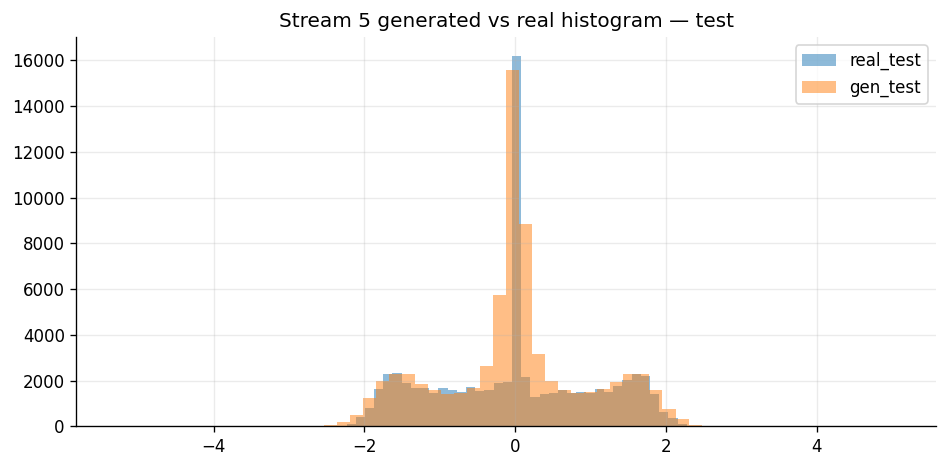

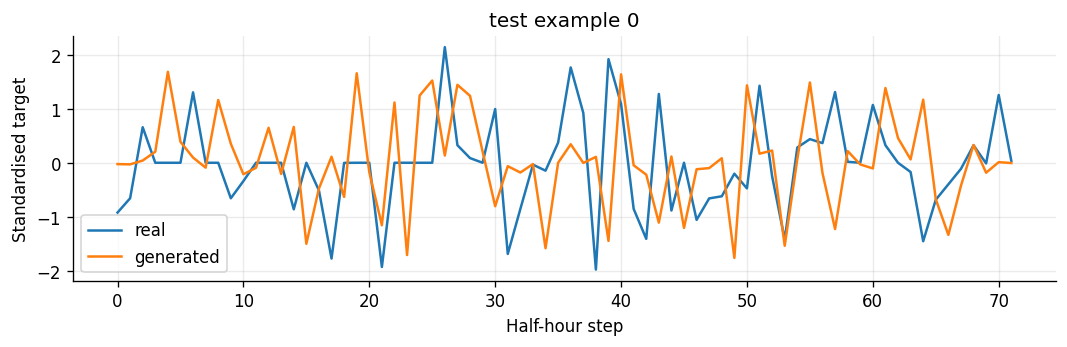

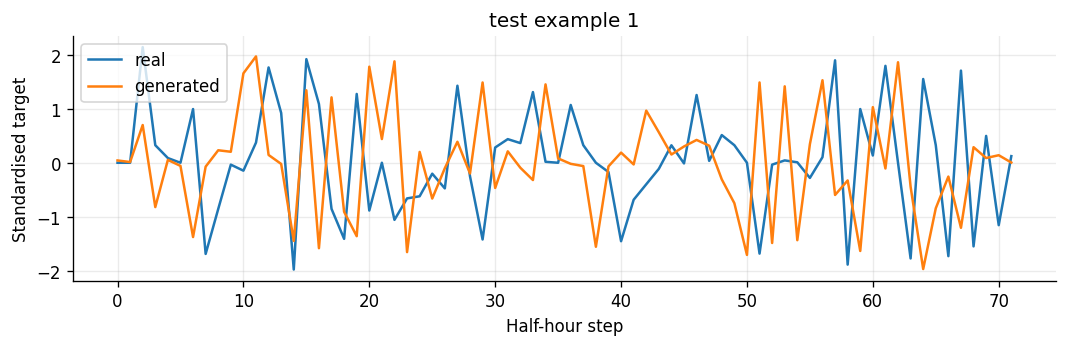

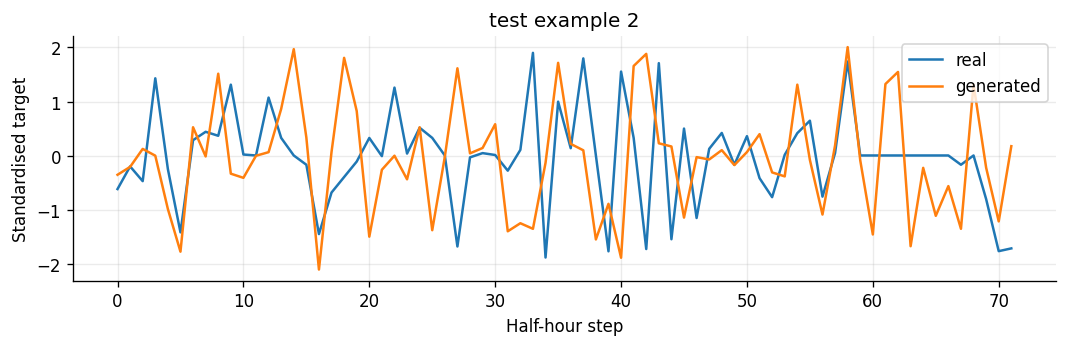

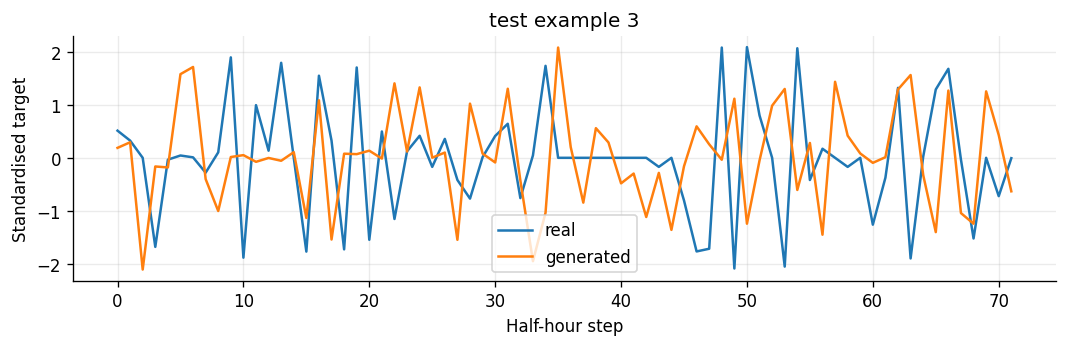

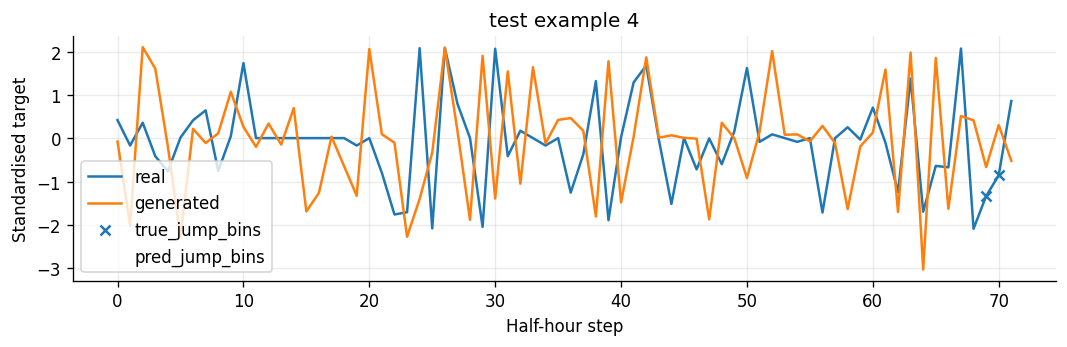

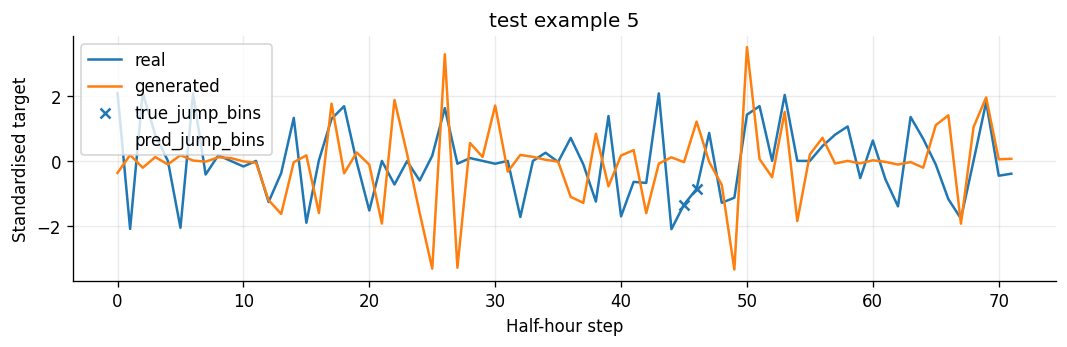

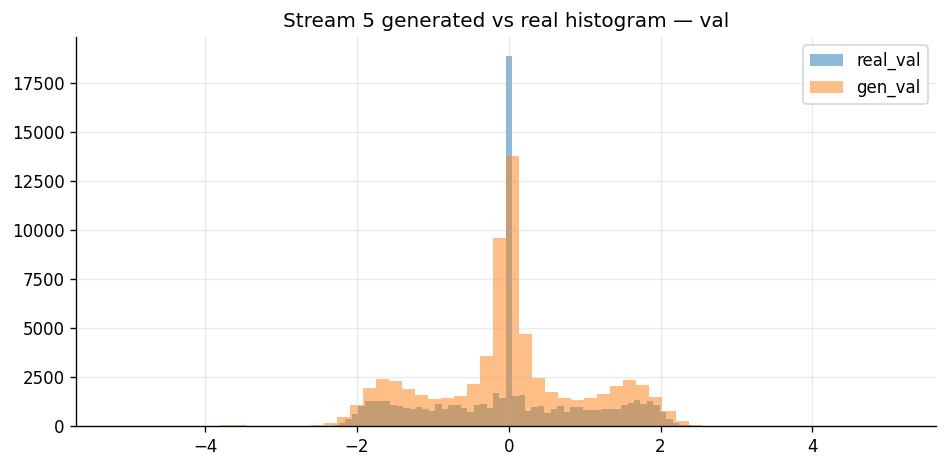

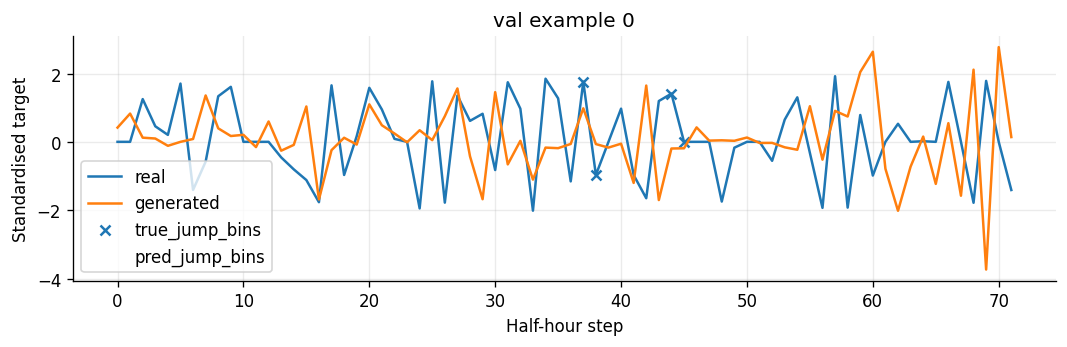

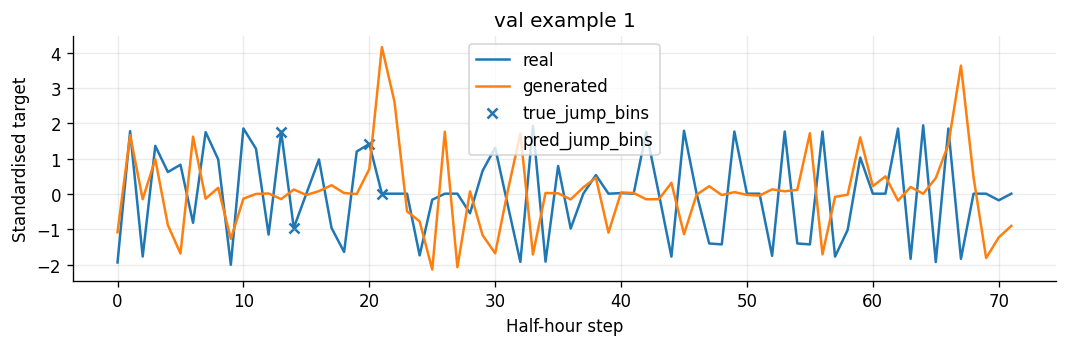

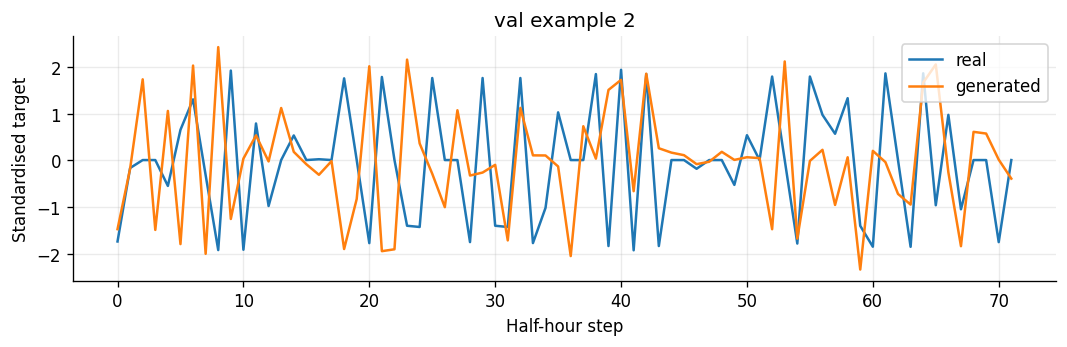

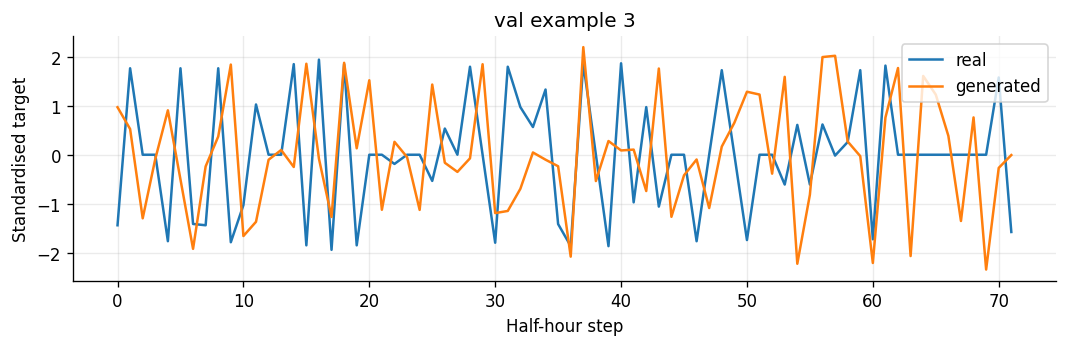

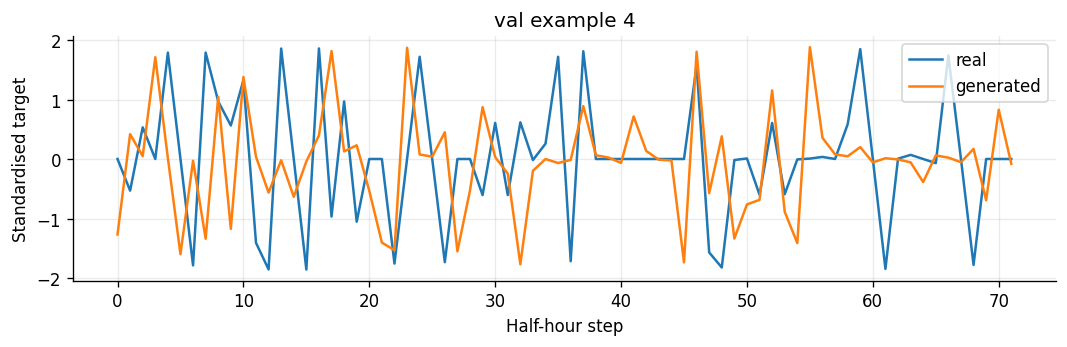

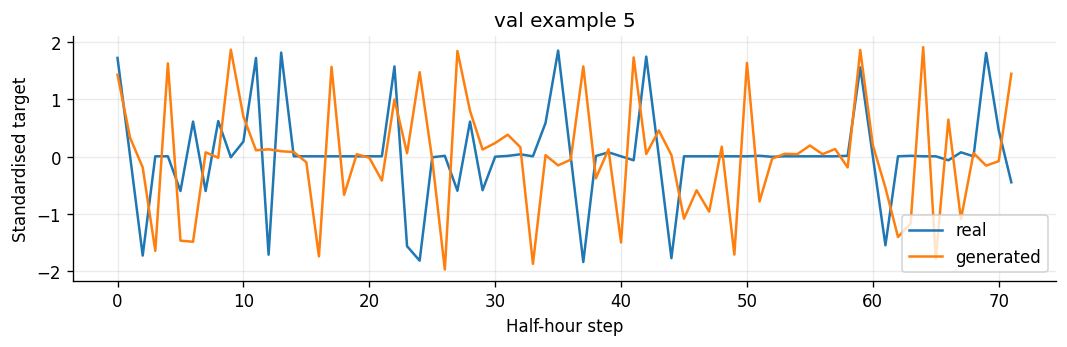

In [17]:
for split_name in diagnostics['split'].tolist():
    real_df = sel.loc[sel['split'].eq(split_name)].copy().reset_index(drop=True)
    gen_df = generated.loc[generated['split'].eq(split_name)].copy().reset_index(drop=True)

    fig = plt.figure(figsize=(8, 4))
    plt.hist(real_df[r_cols].to_numpy().reshape(-1), bins=60, alpha=0.5, label=f'real_{split_name}')
    plt.hist(gen_df[r_cols].to_numpy().reshape(-1), bins=60, alpha=0.5, label=f'gen_{split_name}')
    plt.title(f'Stream 5 generated vs real histogram — {split_name}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f's5_hist_{split_name}.png', dpi=140, bbox_inches='tight')
    plt.show()

    n_show = min(MAX_PLOT_ROWS_PER_SPLIT, len(real_df), len(gen_df))
    for i in range(n_show):
        fig = plt.figure(figsize=(9, 3))
        plt.plot(real_df.iloc[i][r_cols].to_numpy(np.float32), label='real')
        plt.plot(gen_df.iloc[i][r_cols].to_numpy(np.float32), label='generated')
        true_jump_idx = np.where(real_df.iloc[i][mask_cols].to_numpy(np.float32) > 0.5)[0]
        pred_jump_idx = np.where(gen_df.iloc[i][[f'jump_gate_{j:03d}' for j in range(len(r_cols))]].to_numpy(np.float32) > 0.5)[0]
        if len(true_jump_idx) > 0:
            plt.scatter(true_jump_idx, real_df.iloc[i][r_cols].to_numpy(np.float32)[true_jump_idx], marker='x', label='true_jump_bins')
        if len(pred_jump_idx) > 0:
            plt.scatter(pred_jump_idx, gen_df.iloc[i][r_cols].to_numpy(np.float32)[pred_jump_idx], marker='o', facecolors='none', label='pred_jump_bins')
        plt.title(f'{split_name} example {i}')
        plt.xlabel('Half-hour step')
        plt.ylabel('Standardised target')
        plt.legend()
        plt.tight_layout()
        plt.savefig(PLOT_DIR / f's5_example_{split_name}_{i}.png', dpi=140, bbox_inches='tight')
        plt.show()


## 12. Final summary

This final cell prints the canonical outputs produced by this notebook so the next notebook can load them directly.

In [20]:
print('Generation complete.')
print('Generated parquet:', OUT_GENERATED)
print('Diagnostics csv   :', OUT_DIAG_CSV)
print('Manifest json     :', OUT_SUMMARY_JSON)
if SAVE_LOGSIGS and OUT_LOGSIGS.exists():
    print('Logsig parquet    :', OUT_LOGSIGS)
print('Diagnostics:')
display(diagnostics)
print('Manifest:')
print(json.dumps(manifest, indent=2))


Generation complete.
Generated parquet: /content/drive/MyDrive/energy_synthetic_data/data/diffusion_generated.parquet
Diagnostics csv   : /content/drive/MyDrive/energy_synthetic_data/data/s5_generation_diagnostics.csv
Manifest json     : /content/drive/MyDrive/energy_synthetic_data/data/s5_generation_manifest.json
Diagnostics:


,split,n_rows,n_generated_rows,std_gap,tail_gap,central_mass_gap,gen_central_mass,real_central_mass,pred_jump_share,true_jump_share,threshold,temperature,jump_scale
0,test,977,977,0.14466,0.059944,0.084769,0.385932,0.301163,0.006113,0.012510,0.7,1.2,0.75
1,val,973,973,0.14140,0.023178,0.006909,0.362653,0.355744,0.009550,0.029005,0.7,1.2,0.75


Manifest:
{
  "model_checkpoint": "/content/drive/MyDrive/energy_synthetic_data/data/s5_champion_export/s5_diffusion_champion.pt",
  "champion_manifest": "/content/drive/MyDrive/energy_synthetic_data/data/s5_champion_export/s5_diffusion_champion_manifest.json",
  "splits_generated": [
    "val",
    "test"
  ],
  "n_samples_per_cond": 1,
  "n_steps_used": 128,
  "calibration": {
    "threshold": 0.7,
    "temperature": 1.2,
    "jump_scale": 0.75
  },
  "target_kind": "asinh_diff",
  "target_mean": -0.009918324336112642,
  "target_std": 2.048457393160598,
  "asinh_scale": 2.799999999999997,
  "conditioning_dim": 19,
  "hazard_idx": [
    16,
    17,
    18
  ],
  "output_generated_parquet": "/content/drive/MyDrive/energy_synthetic_data/data/diffusion_generated.parquet",
  "output_diag_csv": "/content/drive/MyDrive/energy_synthetic_data/data/s5_generation_diagnostics.csv",
  "output_logsig_parquet": "/content/drive/MyDrive/energy_synthetic_data/data/logsigs_s5_generated.parquet",
  "row

In [23]:
# ============================================================
# Final export: write Stream 5 logsig artifacts for Notebook 05
# This restores the normal project contract:
#   - raw generated parquet
#   - logsig parquet for validator use
# ============================================================
!pip install iisignature
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
import iisignature

DATA_DIR = DRIVE_ROOT / "MyDrive/energy_synthetic_data/data"

REAL_RAW = DATA_DIR / "returns_s5.parquet"
SYNTH_RAW = DATA_DIR / "diffusion_generated.parquet"

REAL_LOGSIG = DATA_DIR / "logsigs_s5_real.parquet"
SYNTH_LOGSIG = DATA_DIR / "logsigs_s5_generated.parquet"

RAW_LOGSIG_DEPTH = 2

if not REAL_RAW.exists():
    raise FileNotFoundError(f"Missing real raw file: {REAL_RAW}")
if not SYNTH_RAW.exists():
    raise FileNotFoundError(f"Missing synthetic raw file: {SYNTH_RAW}")

df_real = pd.read_parquet(REAL_RAW)
df_synth = pd.read_parquet(SYNTH_RAW)

def ordered_path_cols(df: pd.DataFrame):
    cols = list(map(str, df.columns))

    # prefer the standard Stream 5 return columns
    r_cols = sorted(
        [c for c in cols if re.fullmatch(r"r_\d{3}", c)],
        key=lambda x: int(x.split("_")[1])
    )
    if len(r_cols) >= 16:
        return r_cols

    # fallback patterns, just in case
    for pat in [r"raw_diff_\d{3}", r"x_\d{3}"]:
        cc = sorted(
            [c for c in cols if re.fullmatch(pat, c)],
            key=lambda x: int(x.split("_")[-1])
        )
        if len(cc) >= 16:
            return cc

    # generic numeric suffix fallback
    pat = re.compile(r"^(.*?)(\d+)$")
    groups = {}
    for c in cols:
        m = pat.match(c)
        if m:
            prefix, idx = m.group(1), int(m.group(2))
            groups.setdefault(prefix, []).append((idx, c))

    best = []
    for prefix, vals in groups.items():
        vals = sorted(vals)
        idxs = [i for i, _ in vals]
        if len(idxs) >= 16 and idxs == list(range(idxs[0], idxs[0] + len(idxs))):
            candidate = [c for _, c in vals]
            if len(candidate) > len(best):
                best = candidate
    return best

real_path_cols = ordered_path_cols(df_real)
synth_path_cols = ordered_path_cols(df_synth)

if not real_path_cols:
    raise RuntimeError("Could not find ordered real path columns in returns_s5.parquet")
if not synth_path_cols:
    raise RuntimeError("Could not find ordered synthetic path columns in diffusion_generated.parquet")
if len(real_path_cols) != len(synth_path_cols):
    raise RuntimeError(
        f"Real/synth path lengths differ: {len(real_path_cols)} vs {len(synth_path_cols)}"
    )

print("Real path cols  :", real_path_cols[:3], "...", real_path_cols[-3:])
print("Synth path cols :", synth_path_cols[:3], "...", synth_path_cols[-3:])
print("Path length     :", len(real_path_cols))

def lead_lag_lift_univariate(mat_2d: np.ndarray) -> np.ndarray:
    """
    Input  : [n, T]
    Output : [n, 2T-1, 2]
    Standard lead-lag lift for 1D paths.
    """
    x_rep = np.repeat(mat_2d, 2, axis=1)   # [n, 2T]
    lag = x_rep[:, :-1]                    # [n, 2T-1]
    lead = x_rep[:, 1:]                    # [n, 2T-1]
    return np.stack([lag, lead], axis=-1)  # [n, 2T-1, 2]

def logsig_df_from_raw(df: pd.DataFrame, path_cols, depth: int, split_name: str):
    x = df[path_cols].to_numpy(dtype=np.float64)              # [n, T]
    ll = lead_lag_lift_univariate(x)                          # [n, 2T-1, 2]

    spec = iisignature.prepare(2, depth)
    out = np.zeros((ll.shape[0], iisignature.logsiglength(2, depth)), dtype=np.float64)
    for i in range(ll.shape[0]):
        out[i] = iisignature.logsig(ll[i], spec)

    ls_cols = [f"ls_{j+1:03d}" for j in range(out.shape[1])]
    df_ls = pd.DataFrame(out, columns=ls_cols)

    # keep the same metadata columns Notebook 05 expects where available
    meta_cols = []
    for c in ["seg_id", "start_idx", "split", "p0_raw", "p0_log"]:
        if c in df.columns:
            meta_cols.append(c)

    out_df = pd.concat([df[meta_cols].reset_index(drop=True), df_ls], axis=1)

    # if split missing, add it
    if "split" not in out_df.columns:
        out_df["split"] = split_name

    return out_df, ls_cols

real_ls_df, ls_cols_real = logsig_df_from_raw(df_real, real_path_cols, RAW_LOGSIG_DEPTH, split_name="unknown")
synth_ls_df, ls_cols_synth = logsig_df_from_raw(df_synth, synth_path_cols, RAW_LOGSIG_DEPTH, split_name="unknown")

if ls_cols_real != ls_cols_synth:
    raise RuntimeError("Real and synthetic logsig columns do not match")

real_ls_df.to_parquet(REAL_LOGSIG, index=False)
synth_ls_df.to_parquet(SYNTH_LOGSIG, index=False)

manifest_update = {
    "real_raw_file": str(REAL_RAW),
    "synth_raw_file": str(SYNTH_RAW),
    "real_logsig_file": str(REAL_LOGSIG),
    "synth_logsig_file": str(SYNTH_LOGSIG),
    "raw_logsig_depth": RAW_LOGSIG_DEPTH,
    "logsig_transform": "lead_lag_from_1d_raw_paths",
    "n_real_rows": int(len(real_ls_df)),
    "n_synth_rows": int(len(synth_ls_df)),
    "n_logsig_features": int(len(ls_cols_real)),
}

print("\nSaved:")
print(" ", REAL_LOGSIG)
print(" ", SYNTH_LOGSIG)
print("\nManifest update:")
print(json.dumps(manifest_update, indent=2))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for iisignature: filename=iisignature-0.24-cp312-cp312-linux_x86_64.whl size=3246775 sha256=1db4197e689a21d24cb5924b693547690082d4b245e256ef761b16822b0c49dc
  Stored in directory: /root/.cache/pip/wheels/7d/b3/8c/168fb7d3b31255a501dea7fa1f5e5098e63ec61a786eeb0156
Successfully built iisignature
Real path cols  : ['r_000', 'r_001', 'r_002'] ... ['r_069', 'r_070', 'r_071']
Synth path cols : ['r_000', 'r_001', 'r_002'] ... ['r_069', 'r_070', 'r_071']
Path length     : 72

Saved:
  /content/drive/MyDrive/energy_synthetic_data/data/logsigs_s5_real.parquet
  /content/drive/MyDrive/energy_synthetic_data/data/logsigs_s5_generated.parquet

Manifest update:
{
  "real_raw_file": "/content/drive/MyDrive/energy_synthetic_data/data/returns_s5.parquet",
  "synth_raw_file": "/content/drive/MyDrive/energy_synthetic_data/data/diffusion_generated.parquet",
  "real_logsig_

In [24]:
# ============================================================
# Final export for shared validator contract
# Write Stream 5 logsig artifacts so Notebook 05 can be used
# in the same direct-logsig mode as the earlier streams.
# ============================================================

from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import iisignature

DATA_DIR = DRIVE_ROOT / "MyDrive/energy_synthetic_data/data"

REAL_RAW = DATA_DIR / "returns_s5.parquet"
SYNTH_RAW = DATA_DIR / "diffusion_generated.parquet"

REAL_LOGSIG = DATA_DIR / "logsigs_s5_real.parquet"
SYNTH_LOGSIG = DATA_DIR / "logsigs_s5_generated.parquet"

LOGSIG_DEPTH = 4  # gives ls_7 for 2D lead-lag paths

if not REAL_RAW.exists():
    raise FileNotFoundError(f"Missing file: {REAL_RAW}")
if not SYNTH_RAW.exists():
    raise FileNotFoundError(f"Missing file: {SYNTH_RAW}")

df_real = pd.read_parquet(REAL_RAW)
df_synth = pd.read_parquet(SYNTH_RAW)

def ordered_stream5_path_cols(df: pd.DataFrame):
    cols = list(map(str, df.columns))

    # Preferred Stream 5 raw path columns
    r_cols = [c for c in cols if re.fullmatch(r"r_\d{3}", c)]
    r_cols = sorted(r_cols, key=lambda x: int(x.split("_")[1]))
    if len(r_cols) >= 16:
        return r_cols

    # Fallbacks if naming drifted
    for prefix_pat in [r"raw_diff_\d{3}", r"x_\d{3}"]:
        cc = [c for c in cols if re.fullmatch(prefix_pat, c)]
        cc = sorted(cc, key=lambda x: int(x.split("_")[-1]))
        if len(cc) >= 16:
            return cc

    raise RuntimeError("Could not find ordered Stream 5 path columns (expected r_000... etc.)")

real_path_cols = ordered_stream5_path_cols(df_real)
synth_path_cols = ordered_stream5_path_cols(df_synth)

if len(real_path_cols) != len(synth_path_cols):
    raise RuntimeError(
        f"Real and synthetic path lengths differ: {len(real_path_cols)} vs {len(synth_path_cols)}"
    )

print("Using path columns:")
print("  real :", real_path_cols[:3], "...", real_path_cols[-3:])
print("  synth:", synth_path_cols[:3], "...", synth_path_cols[-3:])
print("  T    :", len(real_path_cols))

def lead_lag_lift_univariate(x2d: np.ndarray) -> np.ndarray:
    """
    Input:  [n, T]
    Output: [n, 2T-1, 2]
    """
    x_rep = np.repeat(x2d, 2, axis=1)  # [n, 2T]
    lag = x_rep[:, :-1]
    lead = x_rep[:, 1:]
    return np.stack([lag, lead], axis=-1)

def compute_logsig_df(df: pd.DataFrame, path_cols, depth: int):
    x = df[path_cols].to_numpy(dtype=np.float64)        # [n, T]
    ll = lead_lag_lift_univariate(x)                    # [n, 2T-1, 2]

    spec = iisignature.prepare(2, depth)
    logsig_len = iisignature.logsiglength(2, depth)

    out = np.zeros((ll.shape[0], logsig_len), dtype=np.float64)
    for i in range(ll.shape[0]):
        out[i] = iisignature.logsig(ll[i], spec)

    ls_cols = [f"ls_{j+1}" for j in range(logsig_len)]
    df_ls = pd.DataFrame(out, columns=ls_cols)

    meta_cols = []
    for c in ["seg_id", "start_idx", "split"]:
        if c in df.columns:
            meta_cols.append(c)

    out_df = pd.concat([df[meta_cols].reset_index(drop=True), df_ls], axis=1)
    return out_df, ls_cols

real_ls_df, ls_cols_real = compute_logsig_df(df_real, real_path_cols, LOGSIG_DEPTH)
synth_ls_df, ls_cols_synth = compute_logsig_df(df_synth, synth_path_cols, LOGSIG_DEPTH)

if ls_cols_real != ls_cols_synth:
    raise RuntimeError("Logsignature column mismatch between real and synthetic outputs")

real_ls_df.to_parquet(REAL_LOGSIG, index=False)
synth_ls_df.to_parquet(SYNTH_LOGSIG, index=False)

manifest_update = {
    "real_raw_file": str(REAL_RAW),
    "synth_raw_file": str(SYNTH_RAW),
    "real_logsig_file": str(REAL_LOGSIG),
    "synth_logsig_file": str(SYNTH_LOGSIG),
    "path_cols": real_path_cols,
    "logsig_depth": LOGSIG_DEPTH,
    "transform": "lead_lag_from_1d",
    "n_logsig_features": len(ls_cols_real),
    "example_logsig_cols": ls_cols_real[:8],
}

print("\nSaved:")
print(" ", REAL_LOGSIG)
print(" ", SYNTH_LOGSIG)
print("\nManifest update:")
print(json.dumps(manifest_update, indent=2))

Using path columns:
  real : ['r_000', 'r_001', 'r_002'] ... ['r_069', 'r_070', 'r_071']
  synth: ['r_000', 'r_001', 'r_002'] ... ['r_069', 'r_070', 'r_071']
  T    : 72

Saved:
  /content/drive/MyDrive/energy_synthetic_data/data/logsigs_s5_real.parquet
  /content/drive/MyDrive/energy_synthetic_data/data/logsigs_s5_generated.parquet

Manifest update:
{
  "real_raw_file": "/content/drive/MyDrive/energy_synthetic_data/data/returns_s5.parquet",
  "synth_raw_file": "/content/drive/MyDrive/energy_synthetic_data/data/diffusion_generated.parquet",
  "real_logsig_file": "/content/drive/MyDrive/energy_synthetic_data/data/logsigs_s5_real.parquet",
  "synth_logsig_file": "/content/drive/MyDrive/energy_synthetic_data/data/logsigs_s5_generated.parquet",
  "path_cols": [
    "r_000",
    "r_001",
    "r_002",
    "r_003",
    "r_004",
    "r_005",
    "r_006",
    "r_007",
    "r_008",
    "r_009",
    "r_010",
    "r_011",
    "r_012",
    "r_013",
    "r_014",
    "r_015",
    "r_016",
    "r_017"